# import dataset and clustring

In [81]:
# imports
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import accuracy_score,confusion_matrix,ConfusionMatrixDisplay
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split


In [82]:
# load dataset

iris = load_iris()
iris_df = pd.DataFrame(iris.data, columns=iris.feature_names)
iris_df["target"] = iris.target

X = iris_df.iloc[:, :-1].values
y_true = iris_df["target"].values

In [83]:


def cluster_to_label(y_true, y_cluster):
    y_mapped = np.zeros_like(y_cluster)
    for c in np.unique(y_cluster):
        mask = (y_cluster == c)

        y_mapped[mask] = np.bincount(y_true[mask]).argmax()
    return y_mapped


In [84]:

# KMeans
k_means = KMeans(n_clusters=3, random_state=42)
y_pred_km = k_means.fit_predict(X)
y_pred_km_mapped = cluster_to_label(y_true, y_pred_km)
acc_km = accuracy_score(y_true, y_pred_km_mapped)

# Agglomerative
agg_cluster = AgglomerativeClustering(n_clusters=3,linkage='single')
y_pred_agg = agg_cluster.fit_predict(X)
y_pred_agg_mapped = cluster_to_label(y_true, y_pred_agg)
acc_agg = accuracy_score(y_true, y_pred_agg_mapped)

print("KMeans Accuracy:", acc_km)
print("Agglomerative Accuracy:", acc_agg)


KMeans Accuracy: 0.8866666666666667
Agglomerative Accuracy: 0.68


Accuracy single = 0.68  |
Accuracy ward = 0.8933333333333333  |
Accuracy average = 0.9066666666666666  |
Accuracy complete = 0.84


دقت گزارش شده برای کی مینز مشابه با نتیجه آزمایش بود ! 
ولی دقت گزارش شده برای سلسله مراتبی تجمیعی نسبت به آزمایش داخل مقاله خیلی بالاتر بود 

دقت گزارش شده توی مقاله برای کی مینز = 88.667 

دقت گزارش شده توی مقاله برای سلسله مراتبی = 66 

به نظرم مشکل از اینه که تو مقاله گفته نشده از چه لینک ایجی استفاده شده 

زمانی که لینک ایج رو به سینگل تغییر دادم دقت با مقاله یکی شد ، ولی تا قبل از اون دقت 89 بود 

Pseudo : به معنای شبه لیبل هست چون توسط متخصص ساخته نشده و از طریق خوشه بندی به دست آمده ، و در جهان ما  داده های زیادی وجود دارند که لیبل ندارن و لیبل زدن توسط متخصص هزینه زیادی داره ، نیازه از این روش استفاده بشه 

Accuracy score for all data = 0.98
➖➖➖➖➖
 Epochs500
Accuracy score for test = 0.9777777777777777
➖➖➖➖➖
 Epochs500


e:\MLprojects\tabatabaei_git\MLmoduls\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


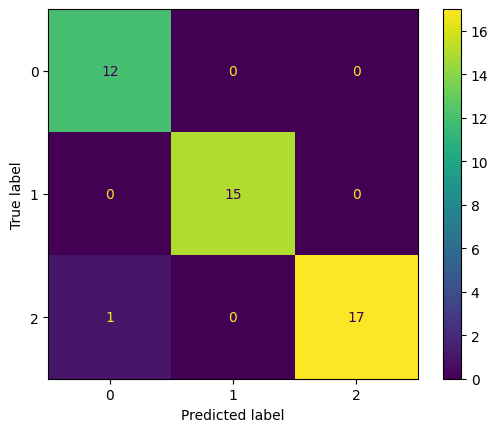

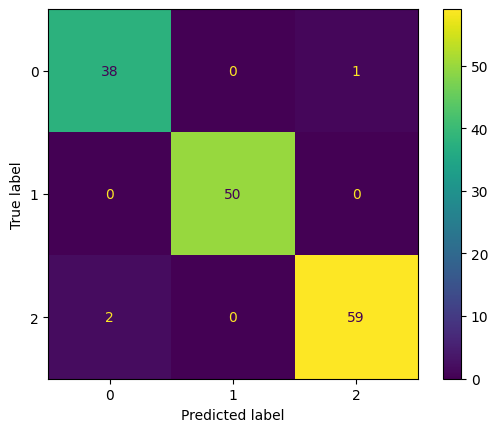

In [85]:
# use Pseudo label for MLP

X,y = iris_df.iloc[:,:-1].copy(deep=True),y_pred_km 
Xtrain,Xtest,ytrain,ytest = train_test_split(X,y,test_size=0.3,random_state=42,shuffle=True,stratify=y)

scaler = StandardScaler()
Xtrain = scaler.fit_transform(Xtrain)
Xtest  = scaler.transform(Xtest)

mlp = MLPClassifier(learning_rate="adaptive",hidden_layer_sizes=(10,10),max_iter=500,random_state=42)
mlp.fit(Xtrain,ytrain)
ypred = mlp.predict(Xtest)

X = scaler.transform(X)
ypred_X = mlp.predict(X)
print(f"Accuracy score for all data = {accuracy_score(y,ypred_X)}\n➖➖➖➖➖\n Epochs{mlp.n_iter_}")

print(f"Accuracy score for test = {accuracy_score(ytest,ypred)}\n➖➖➖➖➖\n Epochs{mlp.n_iter_}")
cm  = confusion_matrix(y_true=ytest,y_pred=ypred)
dsp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=mlp.classes_)
dsp.plot()
plt.show()

cm  = confusion_matrix(y_true=y,y_pred=ypred_X)
dsp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=mlp.classes_)
dsp.plot()
plt.show()

بیشترین خطا مربوط به کلاس سوم است .

با افزایش ایپاک انتظار داریم وزن ها دفعات بیشتری آپدیت بشوند و خطای آنها کاهش پیدا کند 
در اینجا تعداد ایپاک کافی نبوده و با وجود دقت بالا هنوز هم گرا نشده 

Accuracy score for all data = 0.9933333333333333
➖➖➖➖➖
 Epochs814
Accuracy score for test = 0.9777777777777777
➖➖➖➖➖
 Epochs814


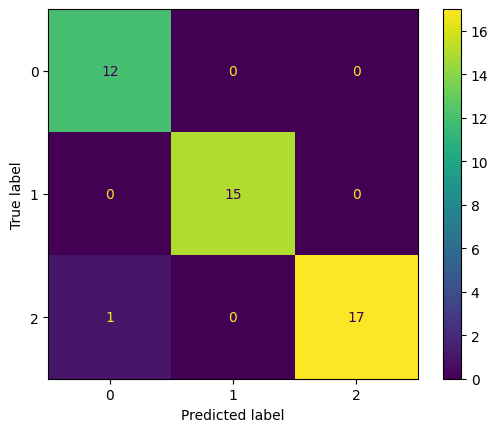

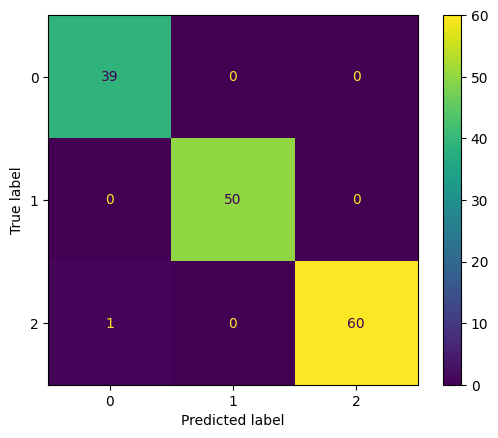

In [86]:
# fit and predict with 1000 iteration
mlp = MLPClassifier(learning_rate="adaptive",hidden_layer_sizes=(10,10),max_iter=1000,random_state=42)
mlp.fit(Xtrain,ytrain)
ypred = mlp.predict(Xtest)


ypred_X = mlp.predict(X)
print(f"Accuracy score for all data = {accuracy_score(y,ypred_X)}\n➖➖➖➖➖\n Epochs{mlp.n_iter_}")

print(f"Accuracy score for test = {accuracy_score(ytest,ypred)}\n➖➖➖➖➖\n Epochs{mlp.n_iter_}")
cm  = confusion_matrix(y_true=ytest,y_pred=ypred)
dsp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=mlp.classes_)
dsp.plot()
plt.show()

cm  = confusion_matrix(y_true=y,y_pred=ypred_X)
dsp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=mlp.classes_)
dsp.plot()
plt.show()

با هزار ایپاک مجاز ، مدل روی 814 توقف کرد

تفکیک خوشه سوم با یه خطا انجام شده 